In [17]:
# 1. 안정적인 얼굴 랜드마크 추출 라이브러리 설치
!pip install face_recognition

# 2. 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=032bf4bf33badaac548236278d10d68f5f997cf3799ceed19decfcefb85b12dc
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import os
import cv2
import json
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import face_recognition

# 1. 경로 설정 (원본 데이터 폴더 및 결과물 저장 폴더)
video_dir = "/content/drive/MyDrive/project23/data/dfdc_train_part_2"
frame_root = "/content/drive/MyDrive/project23/processed_frames"
os.makedirs(frame_root, exist_ok=True)

# 2. 얼굴 턱선 & 입 주변부 마스킹 함수 정의
def apply_facial_mask(frame, img_size=224):
    h, w, _ = frame.shape
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # 랜드마크 찾기
    face_landmarks_list = face_recognition.face_landmarks(rgb_frame)

    # 검은색 빈 캔버스 생성
    mask = np.zeros((h, w), dtype=np.uint8)

    if face_landmarks_list:
        for face_landmarks in face_landmarks_list:
            line_thickness = max(2, int(w * 0.015))

            # [핵심] 턱선(외곽선) 그리기
            if 'chin' in face_landmarks:
                pts = np.array(face_landmarks['chin'], np.int32)
                cv2.polylines(mask, [pts], False, 255, line_thickness)

            # [핵심] 입 주변부 그리기 (윗입술, 아랫입술)
            if 'top_lip' in face_landmarks:
                pts = np.array(face_landmarks['top_lip'], np.int32)
                cv2.polylines(mask, [pts], True, 255, line_thickness)
            if 'bottom_lip' in face_landmarks:
                pts = np.array(face_landmarks['bottom_lip'], np.int32)
                cv2.polylines(mask, [pts], True, 255, line_thickness)

            # 마스크 씌우기 (선이 있는 부분만 원본 픽셀 남김)
            masked_frame = cv2.bitwise_and(frame, frame, mask=mask)

            # 얼굴 전체 좌표를 모아 크롭 영역 계산 (여백 20% 추가)
            all_pts = []
            for feature in face_landmarks.values():
                all_pts.extend(feature)
            all_pts = np.array(all_pts)

            x_min, y_min = np.min(all_pts, axis=0)
            x_max, y_max = np.max(all_pts, axis=0)

            margin_x = int((x_max - x_min) * 0.2)
            margin_y = int((y_max - y_min) * 0.2)

            x_min = max(0, x_min - margin_x)
            x_max = min(w, x_max + margin_x)
            y_min = max(0, y_min - margin_y)
            y_max = min(h, y_max + margin_y)

            cropped_face = masked_frame[y_min:y_max, x_min:x_max]

            # 표준 입력 사이즈(224x224)로 조절
            if cropped_face.size != 0:
                return cv2.resize(cropped_face, (img_size, img_size))

    return None

print("환경 설정 및 마스킹 함수 준비 완료!")

환경 설정 및 마스킹 함수 준비 완료!


In [19]:
# 1. 메타데이터 로드
meta_path = os.path.join(video_dir, "metadata.json")
if os.path.exists(meta_path):
    with open(meta_path, "r") as f:
        meta = json.load(f)
    print(f"메타데이터 로드 완료. (총 {len(meta)}개 영상)")
else:
    print("경고: metadata.json 파일이 없습니다.")
    meta = {}

print("프레임 추출 및 전처리를 시작합니다...")

# 2. 상위 50개 영상 대상 처리 루프
for video_name in list(meta.keys())[:50]:
    label = meta[video_name]["label"]
    video_path = os.path.join(video_dir, video_name)

    # FAKE/REAL 폴더 생성
    save_dir = os.path.join(frame_root, label, video_name[:-4])
    os.makedirs(save_dir, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    idx = 0
    saved = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # 30프레임마다 마스킹 함수 적용
        if idx % 30 == 0:
            processed_frame = apply_facial_mask(frame, img_size=224)

            if processed_frame is not None:
                cv2.imwrite(f"{save_dir}/frame_{saved}.jpg", processed_frame)
                saved += 1

        idx += 1

    cap.release()

print(f"모든 전처리 및 저장 완료! 저장 경로: {frame_root}")

메타데이터 로드 완료. (총 1748개 영상)
프레임 추출 및 전처리를 시작합니다...
모든 전처리 및 저장 완료! 저장 경로: /content/drive/MyDrive/project23/processed_frames


성공적으로 추출 및 마스킹된 이미지 총 개수: 500


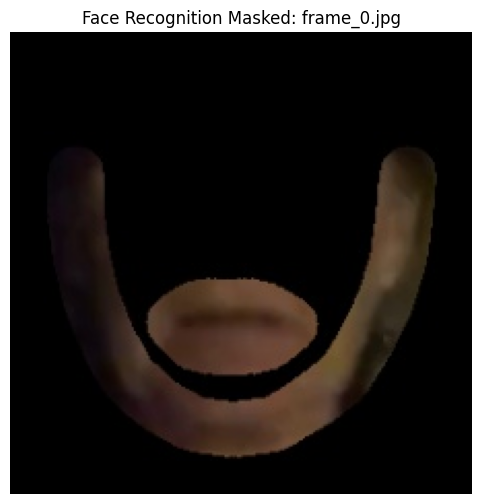

In [20]:
# 저장된 전체 이미지 목록 가져오기
frame_list = glob.glob(f"{frame_root}/*/*/*.jpg")
print(f"성공적으로 추출 및 마스킹된 이미지 총 개수: {len(frame_list)}")

# 첫 번째 이미지 확인
if frame_list:
    img = Image.open(frame_list[0])
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Face Recognition Masked: {os.path.basename(frame_list[0])}")
    plt.axis("off")
    plt.show()
else:
    print("저장된 이미지가 없습니다.")

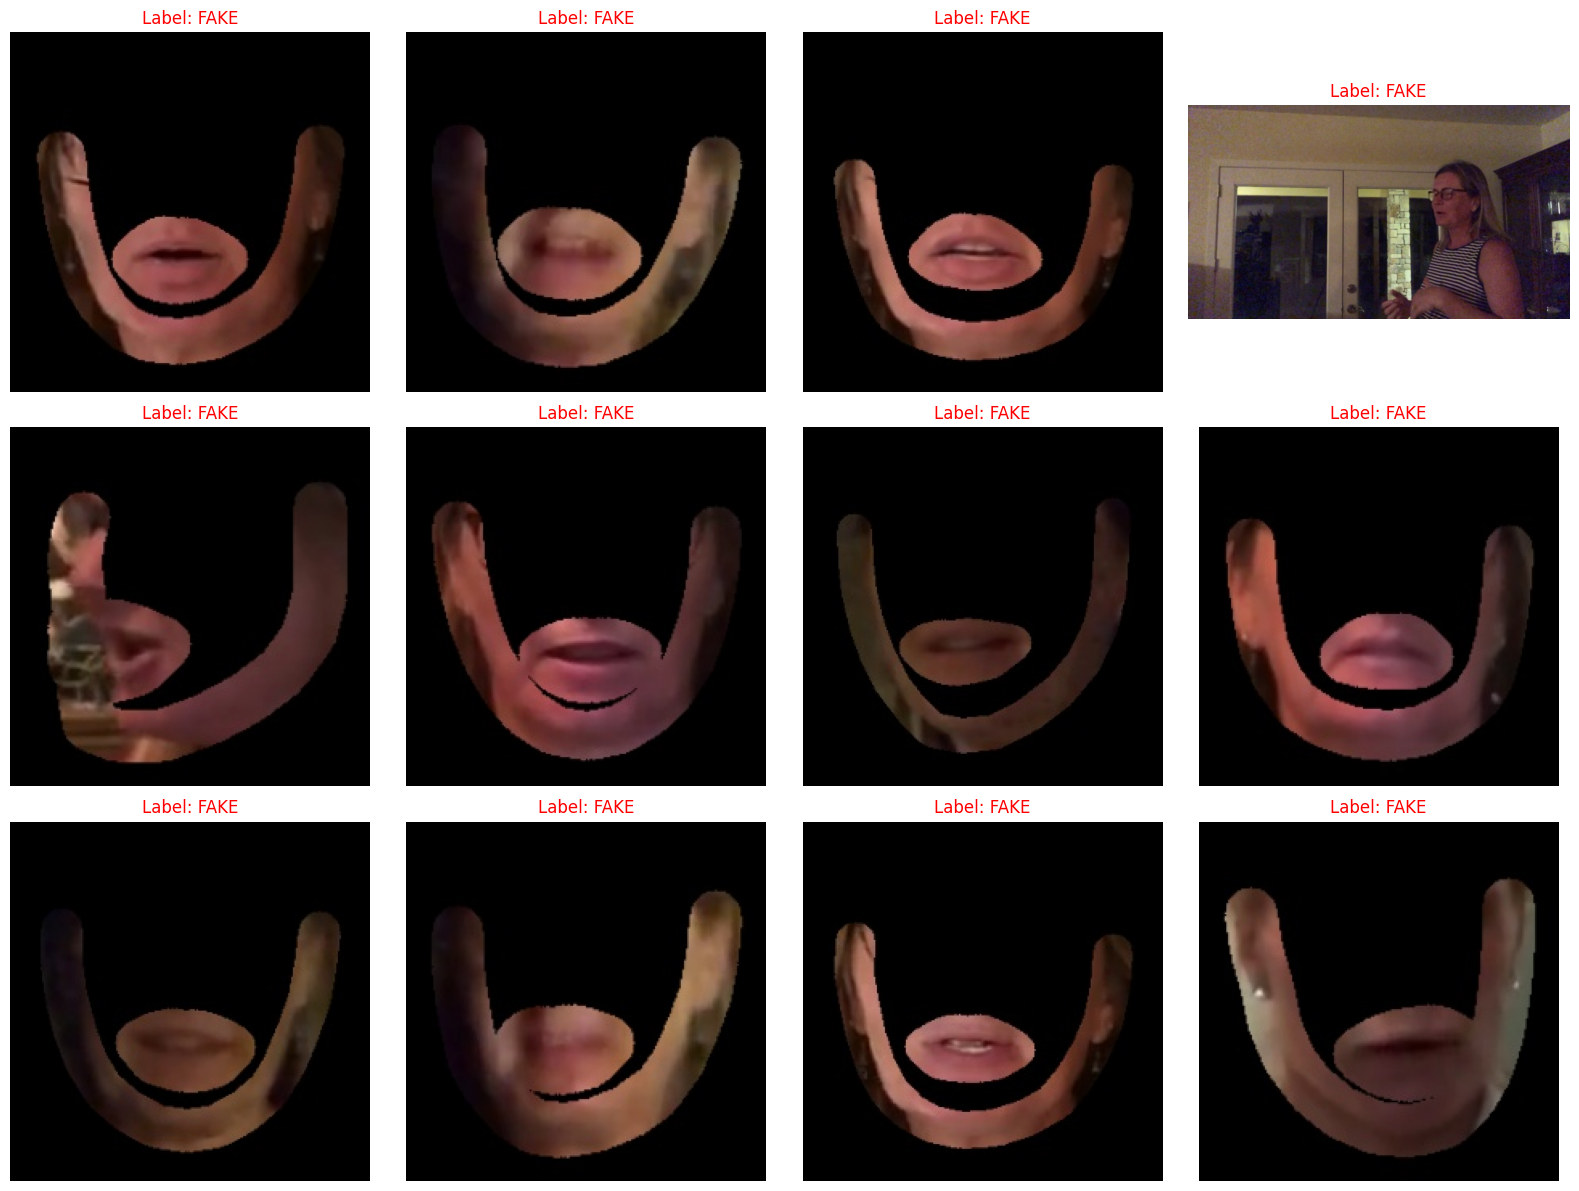

In [21]:
import random

def show_random_results(frame_root, num_images=12):
    # 1. 모든 전처리된 이미지 경로 가져오기
    all_frames = glob.glob(f"{frame_root}/*/*/*.jpg")

    if not all_frames:
        print("시각화할 이미지가 없습니다. 전처리를 먼저 진행해주세요.")
        return

    # 2. 보여줄 이미지 개수 설정 (최대 이미지 수와 비교)
    num_images = min(num_images, len(all_frames))
    sample_frames = random.sample(all_frames, num_images)

    # 3. 시각화 설정 (가로 4개씩 배치)
    cols = 4
    rows = (num_images + cols - 1) // cols
    plt.figure(figsize=(16, rows * 4))

    for i, img_path in enumerate(sample_frames):
        # 경로에서 라벨(FAKE/REAL) 추출
        # 경로 구조: .../processed_frames/LABEL/VIDEO_NAME/frame_X.jpg
        parts = img_path.split('/')
        label = parts[-3]  # 뒤에서 3번째 요소가 라벨

        img = Image.open(img_path)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        # 라벨에 따라 제목 색상 변경 (REAL: 파랑, FAKE: 빨강)
        title_obj = plt.title(f"Label: {label}")
        plt.setp(title_obj, color=('red' if label == 'FAKE' else 'blue'))
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# 함수 실행 (12장의 이미지를 무작위로 확인)
show_random_results(frame_root, num_images=12)